# LIME for Tabular Data
This notebook isolates the Iris example from `lime_interactive.ipynb` and replaces the default LIME bar chart with a cleaner lecture-note figure. The explanation combines a styled horizontal contribution chart with a compact prediction summary, and all exports are written to `out/`.

In [1]:
from pathlib import Path

OUT_DIR = Path('out')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def out_path(filename: str) -> Path:
    return OUT_DIR / filename

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from ipywidgets import IntSlider, interact

from lime.lime_tabular import LimeTabularExplainer
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai_book.plotting import (
    BACKGROUND,
    BLUE as BOOK_BLUE,
    CHAPTER_GRAY,
    GRID as LIGHT_GRAY,
    ORANGE as BOOK_ORANGE,
    apply_notebook_style,
)

apply_notebook_style(figsize=(11.0, 6.0), grid_axis="x")


In [3]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

rf = RandomForestClassifier(n_estimators=200, random_state=0)
rf.fit(X, y)

tabular_explainer = LimeTabularExplainer(
    X,
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    random_state=0,
)

/var/folders/k7/xf0yhfbs02ggfm7n1l5g_cnm0000gn/T/ipykernel_39351/1813562680.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


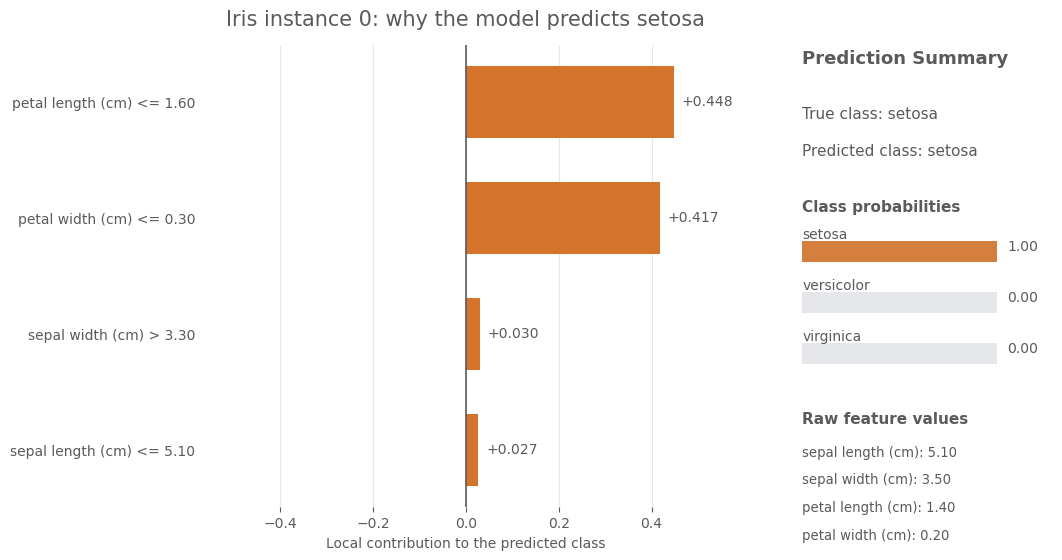

Saved: out/lime_tabular_0.png and out/lime_tabular_0.pdf


,feature,weight
3,petal length (cm) <= 1.60,0.447520
2,petal width (cm) <= 0.30,0.417422
1,sepal width (cm) > 3.30,0.029641
0,sepal length (cm) <= 5.10,0.026710


In [4]:
def plot_lime_bar_chart(idx: int, num_features: int = 4):
    explanation = tabular_explainer.explain_instance(
        X[idx],
        rf.predict_proba,
        num_features=num_features,
        top_labels=1,
    )
    label = explanation.top_labels[0]
    contributions = pd.DataFrame(
        explanation.as_list(label=label),
        columns=['feature', 'weight'],
    )
    contributions['abs_weight'] = contributions['weight'].abs()
    contributions = contributions.sort_values('abs_weight', ascending=True).reset_index(drop=True)

    probs = rf.predict_proba(X[idx].reshape(1, -1))[0]
    pred = int(np.argmax(probs))
    true_label = class_names[y[idx]]
    pred_label = class_names[pred]
    values = X[idx]

    fig = plt.figure(figsize=(11, 6), facecolor=BACKGROUND)
    grid = fig.add_gridspec(1, 2, width_ratios=[3.4, 1.6], wspace=0.18)
    ax = fig.add_subplot(grid[0, 0])
    ax_info = fig.add_subplot(grid[0, 1])

    colors = [BOOK_ORANGE if value >= 0 else BOOK_BLUE for value in contributions['weight']]
    bars = ax.barh(contributions['feature'], contributions['weight'], color=colors, height=0.62)
    ax.axvline(0, color=CHAPTER_GRAY, linewidth=1.2)
    ax.set_title(
        f'Iris instance {idx}: why the model predicts {pred_label}',
        color=CHAPTER_GRAY,
        fontsize=15,
        pad=14,
    )
    ax.set_xlabel('Local contribution to the predicted class', color=CHAPTER_GRAY)
    ax.tick_params(axis='x', colors=CHAPTER_GRAY)
    ax.tick_params(axis='y', colors=CHAPTER_GRAY, length=0, labelsize=10)
    ax.grid(axis='x', color=LIGHT_GRAY, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)

    max_abs = max(0.05, contributions['abs_weight'].max())
    ax.set_xlim(-max_abs * 1.28, max_abs * 1.28)
    for bar, weight in zip(bars, contributions['weight']):
        x = bar.get_width()
        offset = max_abs * 0.04
        ax.text(
            x + (offset if weight >= 0 else -offset),
            bar.get_y() + bar.get_height() / 2,
            f'{weight:+.3f}',
            va='center',
            ha='left' if weight >= 0 else 'right',
            fontsize=10,
            color=CHAPTER_GRAY,
        )

    ax_info.axis('off')
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)
    ax_info.text(0.0, 0.96, 'Prediction Summary', fontsize=13, fontweight='bold', color=CHAPTER_GRAY)
    ax_info.text(0.0, 0.84, f'True class: {true_label}', fontsize=11, color=CHAPTER_GRAY)
    ax_info.text(0.0, 0.76, f'Predicted class: {pred_label}', fontsize=11, color=CHAPTER_GRAY)
    ax_info.text(0.0, 0.64, 'Class probabilities', fontsize=11, fontweight='bold', color=CHAPTER_GRAY)
    for row, (name, prob) in enumerate(zip(class_names, probs)):
        y_pos = 0.56 - row * 0.11
        ax_info.text(0.0, y_pos + 0.02, name, fontsize=10, color=CHAPTER_GRAY)
        ax_info.add_patch(plt.Rectangle((0.0, y_pos - 0.03), 0.78, 0.045, color=LIGHT_GRAY, lw=0))
        ax_info.add_patch(
            plt.Rectangle(
                (0.0, y_pos - 0.03),
                0.78 * float(prob),
                0.045,
                color=BOOK_ORANGE if name == pred_label else BOOK_BLUE,
                alpha=0.9 if name == pred_label else 0.75,
                lw=0,
            )
        )
        ax_info.text(0.82, y_pos - 0.005, f'{prob:.2f}', fontsize=10, color=CHAPTER_GRAY, ha='left')

    ax_info.text(0.0, 0.18, 'Raw feature values', fontsize=11, fontweight='bold', color=CHAPTER_GRAY)
    for row, (name, value) in enumerate(zip(feature_names, values)):
        ax_info.text(0.0, 0.11 - row * 0.06, f'{name}: {value:.2f}', fontsize=9.5, color=CHAPTER_GRAY)

    fig.tight_layout()

    png_path = out_path(f'lime_tabular_{idx}.png')
    pdf_path = out_path(f'lime_tabular_{idx}.pdf')
    fig.savefig(png_path, bbox_inches='tight', dpi=300)
    fig.savefig(pdf_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {png_path} and {pdf_path}')

    display(contributions[['feature', 'weight']].sort_values('weight', ascending=False))

plot_lime_bar_chart(0)


## Interactive exploration
Use the slider to inspect how the local explanation changes from one Iris sample to another while keeping the same visual style.

In [5]:
interact(
    plot_lime_bar_chart,
    idx=IntSlider(min=0, max=X.shape[0] - 1, step=1, value=0, description='Instance'),
)

interactive(children=(IntSlider(value=0, description='Instance', max=149), IntSlider(value=4, description='num…

<function __main__.plot_lime_bar_chart(idx: int, num_features: int = 4)>